In [1]:
# 1. Import Libraries
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
# 2. Load NASA FIRMS Dataset (NO DOWNLOAD NEEDED)
# =========================
url = "https://firms.modaps.eosdis.nasa.gov/data/active_fire/modis-c6.1/csv/MODIS_C6_1_Global_7d.csv"

df = pd.read_csv(url)

print(df.head())
print(df.columns)


   latitude  longitude  brightness  scan  track    acq_date  acq_time  \
0   9.23851  -63.08164      310.30  4.47   1.94  2026-05-03        20   
1   9.23213  -63.12014      309.85  4.50   1.95  2026-05-03        20   
2   9.24217  -63.08704      314.26  4.47   1.94  2026-05-03        20   
3   9.23552  -63.12552      305.49  4.50   1.95  2026-05-03        20   
4 -21.57395  -48.36386      316.56  1.10   1.04  2026-05-03        11   

  satellite  confidence version  bright_t31     frp daynight  
0         T          80  6.1NRT      290.50   72.87        N  
1         T          78  6.1NRT      288.90   71.86        N  
2         T          89  6.1NRT      290.31  102.60        N  
3         T          64  6.1NRT      288.51   49.71        N  
4         T          93  6.1NRT      280.98   18.88        N  
Index(['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date',
       'acq_time', 'satellite', 'confidence', 'version', 'bright_t31', 'frp',
       'daynight'],
      dtyp

In [3]:
# 3. Basic Cleaning
# =========================
df = df.dropna()

In [4]:
# 4. Create Risk Label (IMPORTANT)
# =========================
# Using brightness as proxy for fire intensity

def classify_risk(brightness):
    if brightness < 310:
        return 0   # Low
    elif brightness < 330:
        return 1   # Medium
    else:
        return 2   # High

df['risk'] = df['brightness'].apply(classify_risk)

In [5]:
features = ['scan', 'track', 'confidence', 'frp']
X = df[features]

In [7]:
# 6. Train-Test Split
# =========================
y = df['risk']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [8]:
# 7. Train Random Forest
# =========================
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [9]:
# 8. Predictions
# =========================
y_pred = rf.predict(X_test)

In [10]:
# 9. Evaluation
# =========================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.774073599179382

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.54      0.58      1686
           1       0.80      0.86      0.83      4873
           2       0.87      0.76      0.81      1240

    accuracy                           0.77      7799
   macro avg       0.76      0.72      0.74      7799
weighted avg       0.77      0.77      0.77      7799


Confusion Matrix:
 [[ 917  769    0]
 [ 551 4183  139]
 [   5  298  937]]


In [11]:
# 10. Predict Risk for ALL DATA (for mapping)
# =========================
df['Predicted_Risk'] = rf.predict(X)

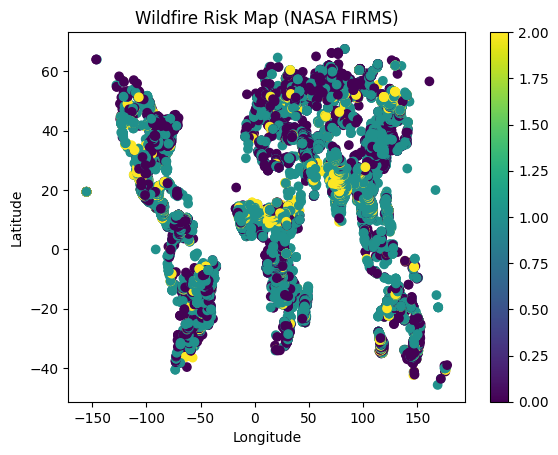

In [12]:
# 11. 🌍 REAL Risk Map Visualization
# =========================
plt.figure()

plt.scatter(
    df['longitude'],
    df['latitude'],
    c=df['Predicted_Risk']
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Wildfire Risk Map (NASA FIRMS)")

plt.colorbar()
plt.show()

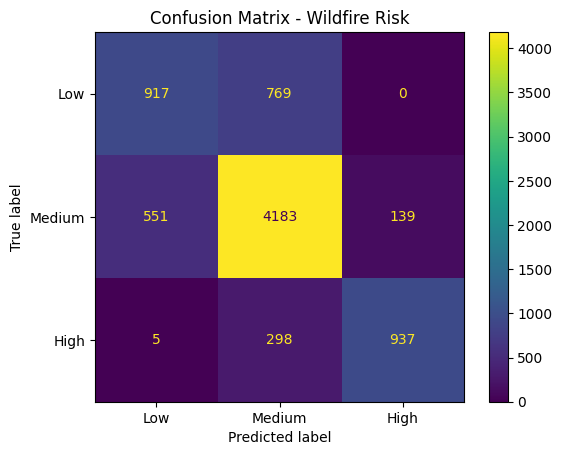

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low", "Medium", "High"]
)

disp.plot()
plt.title("Confusion Matrix - Wildfire Risk")
plt.show()